In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # Check if GPU is available


2.5.1+cu118
True


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
!pip install torch torchvision pillow tqdm


In [ ]:
import os

data_path = r"C:\Github Projects\Leaves"

# Check if dataset folder exists
if os.path.exists(data_path):
    print("✅ Dataset path exists:", data_path)
else:
    print("❌ Dataset path does not exist!")

# Check if 'train' and 'val' folders exist
train_path = os.path.join(data_path, "train")
val_path = os.path.join(data_path, "val")

print("Train folder exists:", os.path.exists(train_path))
print("Val folder exists:", os.path.exists(val_path))

# Check if train classes exist
if os.path.exists(train_path):
    print("\nClasses in train:")
    print(os.listdir(train_path))

# Check if val classes exist
if os.path.exists(val_path):
    print("\nClasses in val:")
    print(os.listdir(val_path))

# Check if images exist in one class folder
example_class = os.path.join(train_path, "Tomato___Bacterial_spot")
if os.path.exists(example_class):
    print(f"\n✅ Images in {example_class}:")
    print(os.listdir(example_class)[:5])  # Show first 5 images
else:
    print(f"\n❌ Class folder {example_class} not found!")


✅ Dataset path exists: C:\Github Projects\Leaves
Train folder exists: True
Val folder exists: True

Classes in train:
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

Classes in val:
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

✅ Images in C:\Github Projects\Leaves\train\Tomato___Bacterial_spot:
['00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG', '01375198-62af-4c40-bddf-f3c11107200b___GCREC_Bact.Sp 5914.JPG', '05777829-6912-44bb-bcef-901bc5190584___GCREC_Bact.Sp 6150.JPG', '0702

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_path = r"C:\Github Projects\Leaves\train"

# Try loading dataset
try:
    dataset = ImageFolder(root=train_path, transform=transform)
    print("✅ Dataset successfully loaded!")
    print(f"Total images: {len(dataset)}")
    print(f"Class mapping: {dataset.class_to_idx}")
except Exception as e:
    print("❌ Error loading dataset:", e)


✅ Dataset successfully loaded!
Total images: 10000
Class mapping: {'Tomato___Bacterial_spot': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___Leaf_Mold': 3, 'Tomato___Septoria_leaf_spot': 4, 'Tomato___Spider_mites Two-spotted_spider_mite': 5, 'Tomato___Target_Spot': 6, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato___Tomato_mosaic_virus': 8, 'Tomato___healthy': 9}


In [ ]:
import torch
import numpy as np
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import os

# Define paths
data_path = r"C:\Github Projects\Leaves"
feature_save_path = r"C:\Github Projects\Leaves\features"
os.makedirs(feature_save_path, exist_ok=True)  # Ensure directory exists

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = ImageFolder(root=os.path.join(data_path, "train"), transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Get labels
labels = np.array([label for _, label in dataset.samples])

# Load Pretrained Models
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device)
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1).to(device)

# Remove final classification layers
resnet50 = torch.nn.Sequential(*list(resnet50.children())[:-1])
mobilenet = torch.nn.Sequential(*list(mobilenet.children())[:-1])

resnet50.eval()
mobilenet.eval()

# Function to extract features
def extract_features(model, dataloader):
    features_list = []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            features = model(images)
            features = features.view(features.size(0), -1)  # Flatten
            features_list.append(features.cpu().numpy())
    return np.vstack(features_list)

# Extract features
print("🔍 Extracting features using ResNet50...")
features_resnet = extract_features(resnet50, dataloader)
print("🔍 Extracting features using MobileNet...")
features_mobilenet = extract_features(mobilenet, dataloader)

# Save features
np.save(os.path.join(feature_save_path, "features_resnet.npy"), features_resnet)
np.save(os.path.join(feature_save_path, "features_mobilenet.npy"), features_mobilenet)
np.save(os.path.join(feature_save_path, "labels.npy"), labels)

print(f"✅ Features saved in: {feature_save_path}")


Using device: cuda
🔍 Extracting features using ResNet50...
🔍 Extracting features using MobileNet...
✅ Features saved in: C:\Github Projects\Leaves\features


In [ ]:
from sklearn.model_selection import train_test_split

# Load features
features_resnet = np.load(os.path.join(feature_save_path, "features_resnet.npy"))
features_mobilenet = np.load(os.path.join(feature_save_path, "features_mobilenet.npy"))
labels = np.load(os.path.join(feature_save_path, "labels.npy"))

# Split dataset using stratification
X_train, X_temp, y_train, y_temp = train_test_split(features_resnet, labels, test_size=0.3, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"✅ Dataset split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

# Save split data
np.save(os.path.join(feature_save_path, "X_train.npy"), X_train)
np.save(os.path.join(feature_save_path, "X_val.npy"), X_val)
np.save(os.path.join(feature_save_path, "X_test.npy"), X_test)
np.save(os.path.join(feature_save_path, "y_train.npy"), y_train)
np.save(os.path.join(feature_save_path, "y_val.npy"), y_val)
np.save(os.path.join(feature_save_path, "y_test.npy"), y_test)


✅ Dataset split: Train=7000, Val=1500, Test=1500


In [ ]:
import numpy as np
from collections import Counter

# ✅ Load features and labels
feature_path_resnet = "C:\\Github Projects\\Leaves\\features\\features_resnet.npy"
feature_path_mobilenet = "C:\\Github Projects\\Leaves\\features\\features_mobilenet.npy"
label_path = "C:\\Github Projects\\Leaves\\features\\labels.npy"

features_resnet = np.load(feature_path_resnet)
features_mobilenet = np.load(feature_path_mobilenet)
labels = np.load(label_path)

# ✅ Check class distribution
label_counts = Counter(labels)
print("📊 Class Distribution Before Splitting:", label_counts)
print(f"✅ Features shape (ResNet50): {features_resnet.shape}")
print(f"✅ Features shape (MobileNet): {features_mobilenet.shape}")
print(f"✅ Labels shape: {labels.shape}")


📊 Class Distribution Before Splitting: Counter({0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000})
✅ Features shape (ResNet50): (10000, 2048)
✅ Features shape (MobileNet): (10000, 62720)
✅ Labels shape: (10000,)


Epoch [1/150], Train Loss: 2.3042, Train Acc: 0.0963, Val Loss: 2.2281, Val Acc: 0.2013
Epoch [2/150], Train Loss: 2.2282, Train Acc: 0.2007, Val Loss: 2.1119, Val Acc: 0.3447
Epoch [3/150], Train Loss: 2.1097, Train Acc: 0.3464, Val Loss: 1.9662, Val Acc: 0.4513
Epoch [4/150], Train Loss: 1.9692, Train Acc: 0.4447, Val Loss: 1.8173, Val Acc: 0.5007
Epoch [5/150], Train Loss: 1.8129, Train Acc: 0.5061, Val Loss: 1.6685, Val Acc: 0.5167
Epoch [6/150], Train Loss: 1.6679, Train Acc: 0.5284, Val Loss: 1.5293, Val Acc: 0.5667
Epoch [7/150], Train Loss: 1.5226, Train Acc: 0.5840, Val Loss: 1.3880, Val Acc: 0.5873
Epoch [8/150], Train Loss: 1.3917, Train Acc: 0.5894, Val Loss: 1.2941, Val Acc: 0.5773
Epoch [9/150], Train Loss: 1.2922, Train Acc: 0.5859, Val Loss: 1.1782, Val Acc: 0.6213
Epoch [10/150], Train Loss: 1.1844, Train Acc: 0.6336, Val Loss: 1.1230, Val Acc: 0.6173
Epoch [11/150], Train Loss: 1.1042, Train Acc: 0.6334, Val Loss: 1.0232, Val Acc: 0.6493
Epoch [12/150], Train Loss: 1.

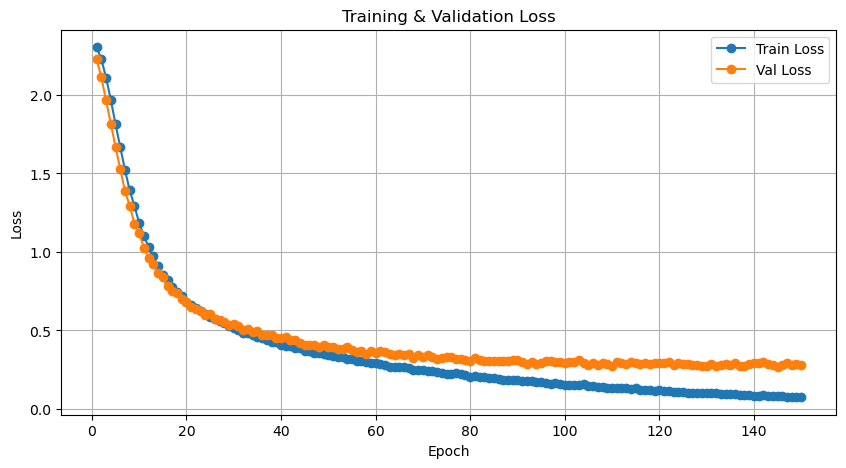

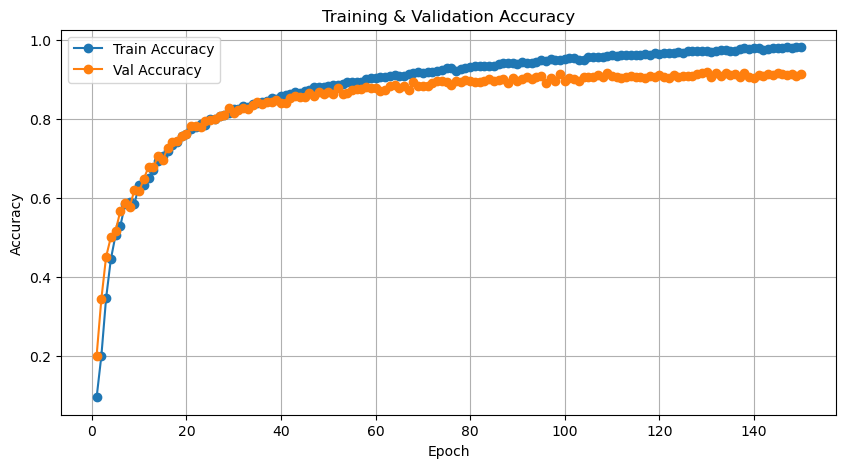

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ✅ Load the split dataset
X_train = np.load("C:\\Github Projects\\Leaves\\features\\X_train.npy")
y_train = np.load("C:\\Github Projects\\Leaves\\features\\y_train.npy")
X_val = np.load("C:\\Github Projects\\Leaves\\features\\X_val.npy")
y_val = np.load("C:\\Github Projects\\Leaves\\features\\y_val.npy")
X_test = np.load("C:\\Github Projects\\Leaves\\features\\X_test.npy")
y_test = np.load("C:\\Github Projects\\Leaves\\features\\y_test.npy")

# ✅ Convert to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# ✅ Define MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ✅ Initialize model
input_dim = X_train.shape[1]  # Feature size
num_classes = len(np.unique(y_train))  # Number of classes
mlp_model = MLP(input_dim, num_classes).to(device)

# ✅ Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# ✅ Training parameters
num_epochs = 150
batch_size = 64

# ✅ Track losses and accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# ✅ Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = mlp_model(X_train_tensor)
    train_loss = criterion(outputs, y_train_tensor)
    train_loss.backward()
    optimizer.step()

    # Compute training accuracy
    _, train_preds = torch.max(outputs, 1)
    train_acc = (train_preds == y_train_tensor).float().mean().item()

    # Validation loss and accuracy
    with torch.no_grad():
        val_outputs = mlp_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        _, val_preds = torch.max(val_outputs, 1)
        val_acc = (val_preds == y_val_tensor).float().mean().item()

    # Store values for plotting
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss.item():.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.4f}")

# ✅ Save trained model
torch.save(mlp_model.state_dict(), "C:\\Github Projects\\Leaves\\features\\mlp_model.pth")
print("✅ MLP model saved!")

# ✅ Final Test Accuracy
with torch.no_grad():
    test_outputs = mlp_model(X_test_tensor)
    _, test_preds = torch.max(test_outputs, 1)
    test_acc = (test_preds == y_test_tensor).float().mean().item()

print(f"📊 Final Test Accuracy: {test_acc:.4f}")

# ✅ Plot Training & Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

# ✅ Plot Training & Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Val Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


Epoch [1/150], Train Loss: 2.3091, Train Acc: 0.0730, Val Loss: 2.2355, Val Acc: 0.2467
Epoch [2/150], Train Loss: 2.2331, Train Acc: 0.2323, Val Loss: 2.1190, Val Acc: 0.3193
Epoch [3/150], Train Loss: 2.1186, Train Acc: 0.3194, Val Loss: 1.9867, Val Acc: 0.4867
Epoch [4/150], Train Loss: 1.9818, Train Acc: 0.4796, Val Loss: 1.8531, Val Acc: 0.4860
Epoch [5/150], Train Loss: 1.8382, Train Acc: 0.4947, Val Loss: 1.6865, Val Acc: 0.5580
Epoch [6/150], Train Loss: 1.6837, Train Acc: 0.5617, Val Loss: 1.5538, Val Acc: 0.5527
Epoch [7/150], Train Loss: 1.5449, Train Acc: 0.5623, Val Loss: 1.4114, Val Acc: 0.5993
Epoch [8/150], Train Loss: 1.4044, Train Acc: 0.6051, Val Loss: 1.3199, Val Acc: 0.5973
Epoch [9/150], Train Loss: 1.3093, Train Acc: 0.6064, Val Loss: 1.2023, Val Acc: 0.6107
Epoch [10/150], Train Loss: 1.2063, Train Acc: 0.6081, Val Loss: 1.1250, Val Acc: 0.6180
Epoch [11/150], Train Loss: 1.1190, Train Acc: 0.6441, Val Loss: 1.0464, Val Acc: 0.6373
Epoch [12/150], Train Loss: 1.

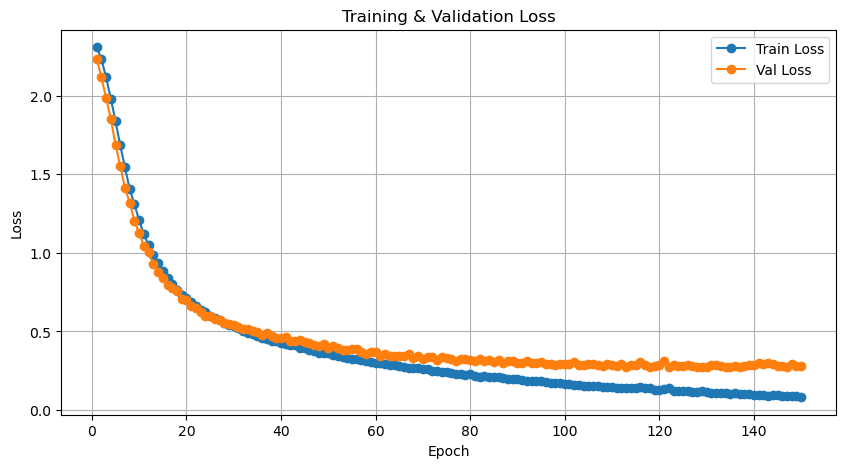

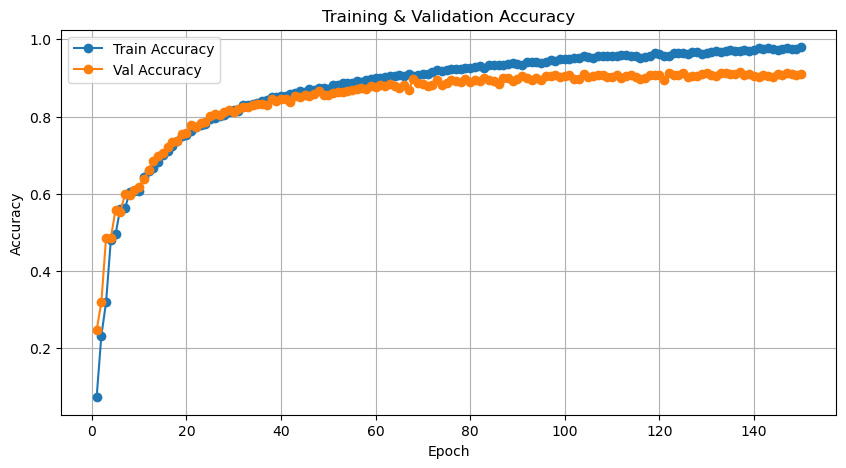

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ✅ Load the split dataset
X_train = np.load("C:\\Github Projects\\Leaves\\features\\X_train.npy")
y_train = np.load("C:\\Github Projects\\Leaves\\features\\y_train.npy")
X_val = np.load("C:\\Github Projects\\Leaves\\features\\X_val.npy")
y_val = np.load("C:\\Github Projects\\Leaves\\features\\y_val.npy")
X_test = np.load("C:\\Github Projects\\Leaves\\features\\X_test.npy")
y_test = np.load("C:\\Github Projects\\Leaves\\features\\y_test.npy")

# ✅ Convert to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# ✅ Define MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ✅ Initialize model
input_dim = X_train.shape[1]  # Feature size
num_classes = len(np.unique(y_train))  # Number of classes
mlp_model = MLP(input_dim, num_classes).to(device)

# ✅ Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# ✅ Training parameters
num_epochs = 150
batch_size = 64

# ✅ Track losses and accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# ✅ Training loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = mlp_model(X_train_tensor)
    train_loss = criterion(outputs, y_train_tensor)
    train_loss.backward()
    optimizer.step()

    # Compute training accuracy
    _, train_preds = torch.max(outputs, 1)
    train_acc = (train_preds == y_train_tensor).float().mean().item()

    # Validation loss and accuracy
    with torch.no_grad():
        val_outputs = mlp_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        _, val_preds = torch.max(val_outputs, 1)
        val_acc = (val_preds == y_val_tensor).float().mean().item()

    # Store values for plotting
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_loss.item():.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.4f}")

# ✅ Save trained model
torch.save(mlp_model.state_dict(), "C:\\Github Projects\\Leaves\\features\\mlp_model.pth")
print("✅ MLP model saved!")

# ✅ Final Test Accuracy
with torch.no_grad():
    test_outputs = mlp_model(X_test_tensor)
    _, test_preds = torch.max(test_outputs, 1)
    test_acc = (test_preds == y_test_tensor).float().mean().item()

print(f"📊 Final Test Accuracy: {test_acc:.4f}")

# ✅ Plot Training & Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

# ✅ Plot Training & Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), val_accuracies, label="Val Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


✅ Model Loaded Successfully!
📊 Accuracy: 0.9173
🎯 F1 Score: 0.9176
🎯 Precision: 0.9185
🎯 Recall (Sensitivity): 0.9173
🎯 Specificity: 0.9908

📜 Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93       150
           1       0.82      0.86      0.84       150
           2       0.92      0.89      0.91       150
           3       0.90      0.92      0.91       150
           4       0.95      0.87      0.91       150
           5       0.91      0.90      0.91       150
           6       0.85      0.88      0.86       150
           7       0.99      0.95      0.97       150
           8       0.96      0.99      0.97       150
           9       0.97      0.96      0.97       150

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



C:\Users\sami3\AppData\Local\Temp\ipykernel_46448\2191283196.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mlp_model.load_state_dict(torch.load("C:\\Github Projects\\

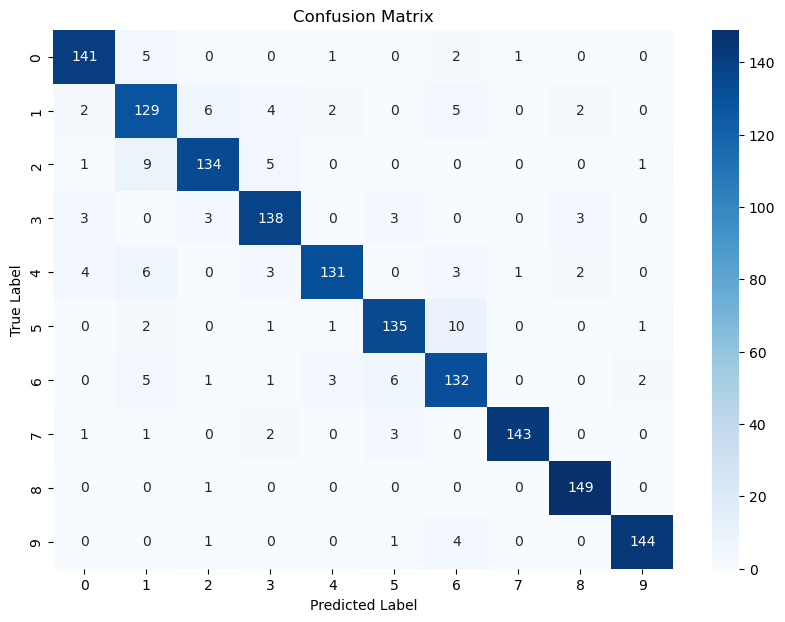

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import torch
import numpy as np
import matplotlib.pyplot as plt

# ✅ Load test set
X_test = np.load("C:\\Github Projects\\Leaves\\features\\X_test.npy")
y_test = np.load("C:\\Github Projects\\Leaves\\features\\y_test.npy")

# ✅ Convert test data to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# ✅ Load trained model
input_dim = X_test.shape[1]  # Feature size
num_classes = len(np.unique(y_test))  # Number of classes
mlp_model = MLP(input_dim, num_classes).to(device)

try:
    mlp_model.load_state_dict(torch.load("C:\\Github Projects\\Leaves\\features\\mlp_model.pth"))
    mlp_model.eval()
    print("✅ Model Loaded Successfully!")
except FileNotFoundError as e:
    print(f"❌ Model file not found: {e}")

# ✅ Get predictions
with torch.no_grad():
    test_outputs = mlp_model(X_test_tensor)
    _, test_preds = torch.max(test_outputs, 1)
    test_preds = test_preds.cpu().numpy()
    y_test = y_test_tensor.cpu().numpy()

# ✅ Compute evaluation metrics
accuracy = accuracy_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds, average='weighted')
precision = precision_score(y_test, test_preds, average='weighted')
recall = recall_score(y_test, test_preds, average='weighted')

# ✅ Compute specificity (class-wise)
conf_matrix = confusion_matrix(y_test, test_preds)
specificity = []
for i in range(num_classes):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity.append(tn / (tn + fp))

# ✅ Print results
print(f"📊 Accuracy: {accuracy:.4f}")
print(f"🎯 F1 Score: {f1:.4f}")
print(f"🎯 Precision: {precision:.4f}")
print(f"🎯 Recall (Sensitivity): {recall:.4f}")
print(f"🎯 Specificity: {np.mean(specificity):.4f}")

# ✅ Show class-wise report
print("\n📜 Classification Report:\n", classification_report(y_test, test_preds))

# ✅ Plot Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


Class Distribution Before Splitting: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
Train Size: 7000, Validation Size: 1500, Test Size: 1500
🔹 Total Trainable Parameters: 32247050
Epoch [1/80], Loss: 2.3011, Val Loss: 1.7645, Train Acc: 0.1063, Val Acc: 0.6200
Epoch [2/80], Loss: 1.7392, Val Loss: 1.3449, Train Acc: 0.6559, Val Acc: 0.6660
Epoch [3/80], Loss: 1.3050, Val Loss: 1.0540, Train Acc: 0.7129, Val Acc: 0.7187
Epoch [4/80], Loss: 0.9985, Val Loss: 0.8527, Train Acc: 0.7594, Val Acc: 0.7493
Epoch [5/80], Loss: 0.7826, Val Loss: 0.7152, Train Acc: 0.7977, Val Acc: 0.7833
Epoch [6/80], Loss: 0.6319, Val Loss: 0.6221, Train Acc: 0.8214, Val Acc: 0.8073
Epoch [7/80], Loss: 0.5255, Val Loss: 0.5565, Train Acc: 0.8461, Val Acc: 0.8187
Epoch [8/80], Loss: 0.4457, Val Loss: 0.5065, Train Acc: 0.8667, Val Acc: 0.8280
Epoch [9/80], Loss: 0.3813, Val Loss: 0.4664, Train Acc: 0.8829, Val Acc: 0.8413
Epoch [10/80], Loss: 0.3273, Val Loss: 0.4338, 

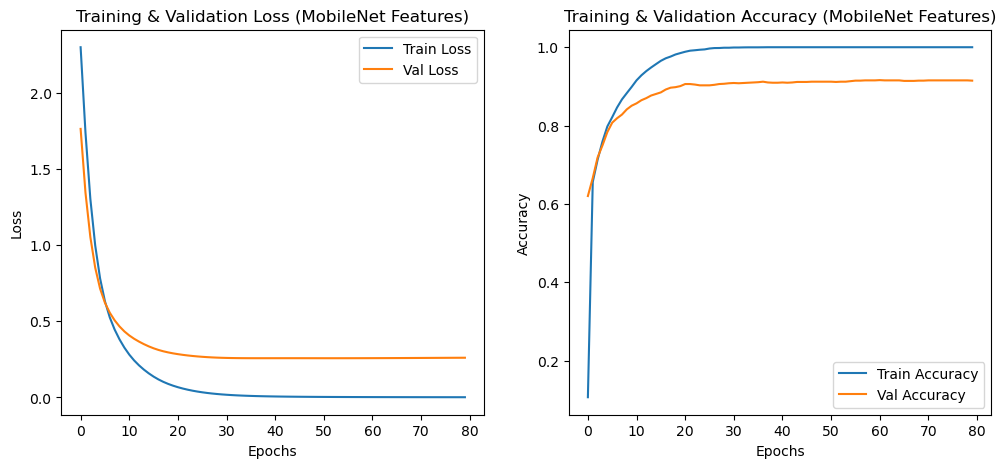


🔹 Accuracy: 0.9200
🔹 Precision: 0.9206
🔹 Recall (Sensitivity): 0.9200
🔹 F1 Score: 0.9199
🔹 Inference Time per Sample: 0.0000 ms
🔹 GPU memory allocated: 2901.42 MB
🔹 Max GPU memory reserved: 3218.00 MB


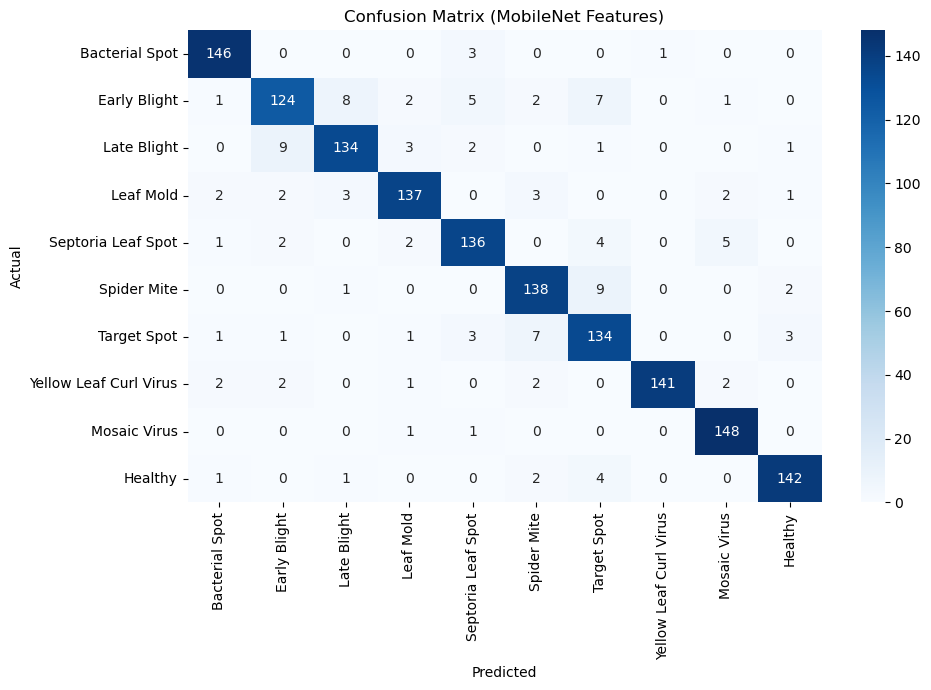

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import time

# Load MobileNet features and labels
feature_path = "C:\\Github Projects\\Leaves\\features\\features_mobilenet.npy"
label_path = "C:\\Github Projects\\Leaves\\features\\labels.npy"
features = np.load(feature_path)
labels = np.load(label_path)

# Check class distribution
unique_classes, class_counts = np.unique(labels, return_counts=True)
print("Class Distribution Before Splitting:", dict(zip(unique_classes, class_counts)))

# Train-validation-test split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train Size: {len(X_train)}, Validation Size: {len(X_val)}, Test Size: {len(X_test)}")

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Define MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model
input_dim = X_train.shape[1]
num_classes = len(unique_classes)
mlp_model = MLP(input_dim, num_classes).to(device)

# Print model parameters
total_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"🔹 Total Trainable Parameters: {total_params}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.0001)

# Train model
num_epochs = 80
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

start_time = time.time()

for epoch in range(num_epochs):
    mlp_model.train()
    optimizer.zero_grad()
    outputs = mlp_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    _, predicted_train = torch.max(outputs, 1)
    train_acc = (predicted_train == y_train_tensor).float().mean().item()

    mlp_model.eval()
    with torch.no_grad():
        val_outputs = mlp_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        _, predicted_val = torch.max(val_outputs, 1)
        val_acc = (predicted_val == y_val_tensor).float().mean().item()

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

end_time = time.time()
print(f"\n🔹 Total Training Time: {end_time - start_time:.2f} seconds")

# Plot loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (MobileNet Features)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (MobileNet Features)")
plt.legend()
plt.show()

# Evaluate on test set
mlp_model.eval()
with torch.no_grad():
    inference_start = time.time()
    test_outputs = mlp_model(X_test_tensor)
    inference_end = time.time()
    _, y_pred = torch.max(test_outputs, 1)

y_test_np = y_test_tensor.cpu().numpy()
y_pred_np = y_pred.cpu().numpy()

# Compute metrics
accuracy = accuracy_score(y_test_np, y_pred_np)
precision = precision_score(y_test_np, y_pred_np, average='macro')
recall = recall_score(y_test_np, y_pred_np, average='macro')
f1 = f1_score(y_test_np, y_pred_np, average='macro')

print(f"\n🔹 Accuracy: {accuracy:.4f}")
print(f"🔹 Precision: {precision:.4f}")
print(f"🔹 Recall (Sensitivity): {recall:.4f}")
print(f"🔹 F1 Score: {f1:.4f}")
print(f"🔹 Inference Time per Sample: {(inference_end - inference_start)/len(y_test_np)*1000:.4f} ms")

# Optional GPU memory usage
if torch.cuda.is_available():
    print(f"🔹 GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"🔹 Max GPU memory reserved: {torch.cuda.max_memory_reserved() / 1024**2:.2f} MB")

# Confusion matrix
class_labels = ['Bacterial Spot', 'Early Blight', 'Late Blight', 'Leaf Mold',
                'Septoria Leaf Spot', 'Spider Mite', 'Target Spot',
                'Yellow Leaf Curl Virus', 'Mosaic Virus', 'Healthy']

conf_matrix = confusion_matrix(y_test_np, y_pred_np)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (MobileNet Features)")
plt.tight_layout()
plt.show()


Class Distribution Before Splitting: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}
Train Size: 7000, Validation Size: 1500, Test Size: 1500
🔹 Total Trainable Parameters: 1182986
Epoch [1/80], Loss: 2.3219, Val Loss: 1.9569, Train Acc: 0.0709, Val Acc: 0.6233
Epoch [2/80], Loss: 1.9548, Val Loss: 1.5800, Train Acc: 0.6284, Val Acc: 0.6547
Epoch [3/80], Loss: 1.5770, Val Loss: 1.2132, Train Acc: 0.6673, Val Acc: 0.6767
Epoch [4/80], Loss: 1.2108, Val Loss: 0.9386, Train Acc: 0.6899, Val Acc: 0.7233
Epoch [5/80], Loss: 0.9361, Val Loss: 0.7613, Train Acc: 0.7207, Val Acc: 0.7533
Epoch [6/80], Loss: 0.7554, Val Loss: 0.6596, Train Acc: 0.7549, Val Acc: 0.7767
Epoch [7/80], Loss: 0.6451, Val Loss: 0.5896, Train Acc: 0.7827, Val Acc: 0.8020
Epoch [8/80], Loss: 0.5663, Val Loss: 0.5404, Train Acc: 0.8060, Val Acc: 0.8147
Epoch [9/80], Loss: 0.5078, Val Loss: 0.4994, Train Acc: 0.8253, Val Acc: 0.8333
Epoch [10/80], Loss: 0.4596, Val Loss: 0.4693, T

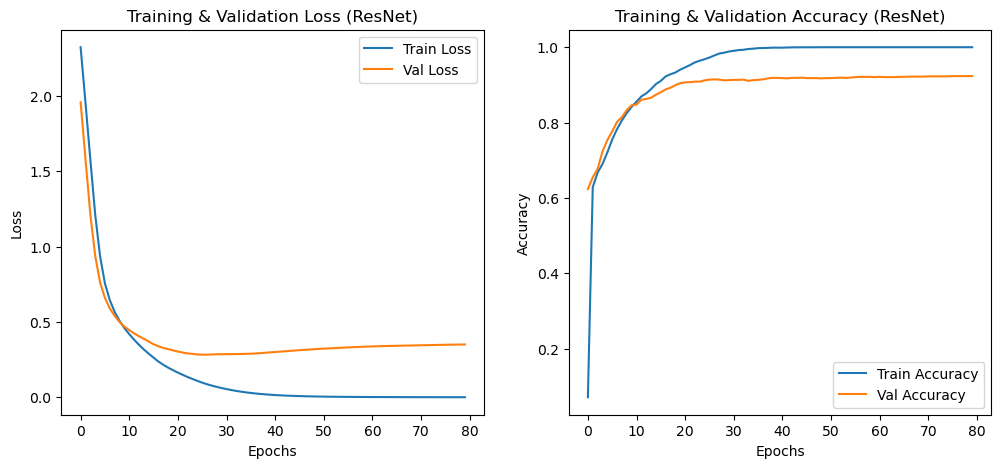

🔹 Total Inference Time: 0.0000 seconds
🔹 Avg Inference Time per Sample: 0.0000 ms
🔹 GPU memory allocated: 113.53 MB
🔹 Max GPU memory reserved: 200.00 MB

🔹 Accuracy: 0.9253
🔹 Precision: 0.9259
🔹 Recall (Sensitivity): 0.9253
🔹 F1 Score: 0.9254


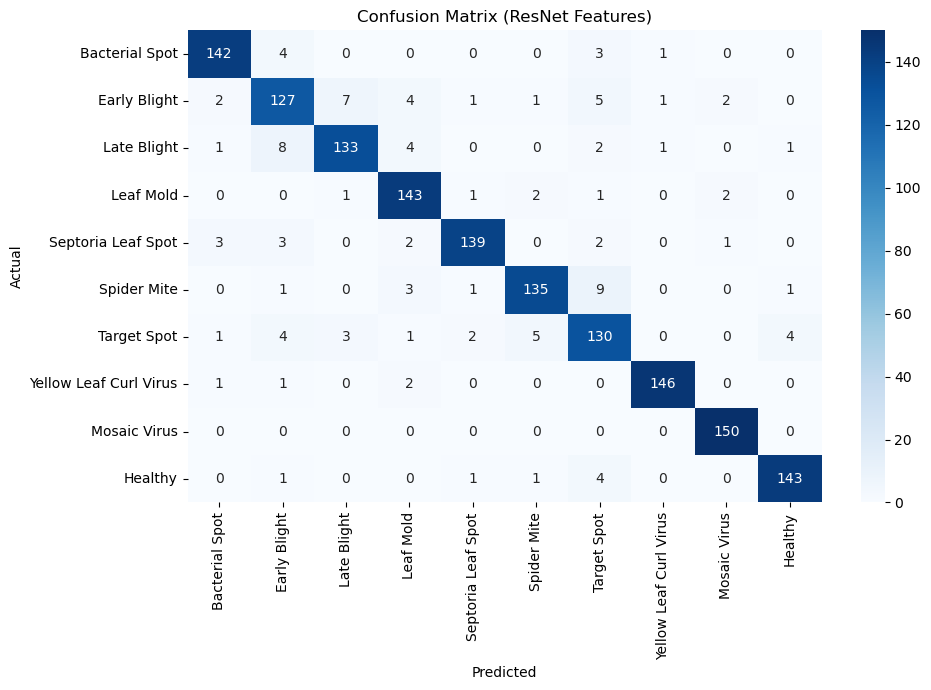

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import time

# Load ResNet features and labels
feature_path = "C:\\Github Projects\\Leaves\\features\\features_resnet.npy"
label_path = "C:\\Github Projects\\Leaves\\features\\labels.npy"
features = np.load(feature_path)
labels = np.load(label_path)

# Check class distribution
unique_classes, class_counts = np.unique(labels, return_counts=True)
print("Class Distribution Before Splitting:", dict(zip(unique_classes, class_counts)))

# Stratified split
X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"Train Size: {len(X_train)}, Validation Size: {len(X_val)}, Test Size: {len(X_test)}")

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# Define MLP
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model
input_dim = X_train.shape[1]
num_classes = len(unique_classes)
mlp_model = MLP(input_dim, num_classes).to(device)

# Print model parameters
total_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"🔹 Total Trainable Parameters: {total_params}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# Train model
num_epochs = 80
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

start_time = time.time()

for epoch in range(num_epochs):
    mlp_model.train()
    optimizer.zero_grad()
    outputs = mlp_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    # Training accuracy
    _, predicted_train = torch.max(outputs, 1)
    train_acc = (predicted_train == y_train_tensor).float().mean().item()

    # Validation
    mlp_model.eval()
    with torch.no_grad():
        val_outputs = mlp_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        _, predicted_val = torch.max(val_outputs, 1)
        val_acc = (predicted_val == y_val_tensor).float().mean().item()

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

end_time = time.time()
print(f"\n🔹 Total Training Time: {end_time - start_time:.2f} seconds")

# Plot loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (ResNet)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (ResNet)")
plt.legend()
plt.show()

# Inference time
mlp_model.eval()
with torch.no_grad():
    inference_start = time.time()
    test_outputs = mlp_model(X_test_tensor)
    inference_end = time.time()
    _, y_pred = torch.max(test_outputs, 1)

total_inference_time = inference_end - inference_start
avg_inference_time = total_inference_time / X_test_tensor.shape[0]
print(f"🔹 Total Inference Time: {total_inference_time:.4f} seconds")
print(f"🔹 Avg Inference Time per Sample: {avg_inference_time*1000:.4f} ms")

# Optional GPU memory usage
if torch.cuda.is_available():
    print(f"🔹 GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"🔹 Max GPU memory reserved: {torch.cuda.max_memory_reserved() / 1024**2:.2f} MB")

# Metrics
y_test_np = y_test_tensor.cpu().numpy()
y_pred_np = y_pred.cpu().numpy()
accuracy = accuracy_score(y_test_np, y_pred_np)
precision = precision_score(y_test_np, y_pred_np, average='macro')
recall = recall_score(y_test_np, y_pred_np, average='macro')
f1 = f1_score(y_test_np, y_pred_np, average='macro')

print(f"\n🔹 Accuracy: {accuracy:.4f}")
print(f"🔹 Precision: {precision:.4f}")
print(f"🔹 Recall (Sensitivity): {recall:.4f}")
print(f"🔹 F1 Score: {f1:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_np, y_pred_np)
class_labels = ['Bacterial Spot', 'Early Blight', 'Late Blight', 'Leaf Mold',
               'Septoria Leaf Spot', 'Spider Mite', 'Target Spot',
               'Yellow Leaf Curl Virus', 'Mosaic Virus', 'Healthy']

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (ResNet Features)")
plt.tight_layout()
plt.show()



🎯 Training SVM...

✅ Test Accuracy: 0.9047

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       150
           1       0.83      0.81      0.82       150
           2       0.94      0.89      0.91       150
           3       0.87      0.91      0.89       150
           4       0.93      0.87      0.90       150
           5       0.87      0.88      0.87       150
           6       0.81      0.87      0.84       150
           7       1.00      0.91      0.95       150
           8       0.93      1.00      0.96       150
           9       0.97      0.95      0.96       150

    accuracy                           0.90      1500
   macro avg       0.91      0.90      0.90      1500
weighted avg       0.91      0.90      0.90      1500



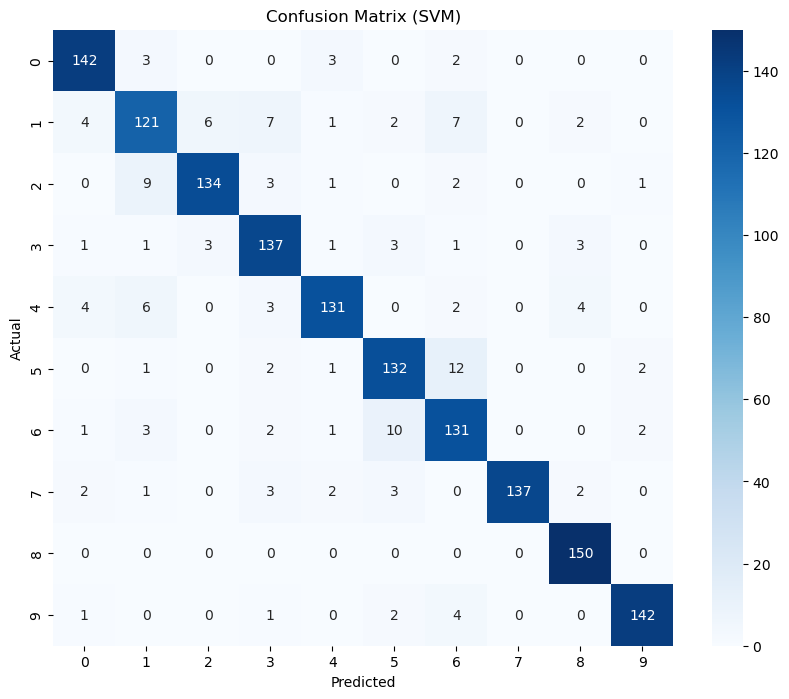

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load extracted features
feature_path = "C:\\Github Projects\\Leaves\\features\\features_resnet.npy"
label_path = "C:\\Github Projects\\Leaves\\features\\labels.npy"

X = np.load(feature_path)
y = np.load(label_path)

# Split dataset (Stratified)
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# ✅ Train SVM
print("\n🎯 Training SVM...")
svm_model = SVC(kernel="rbf", C=1.0, probability=True)
svm_model.fit(X_train, y_train)

# ✅ Evaluate SVM
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")

# Classification Report
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.show()
